In [1]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

In [2]:
def kron(*args):
    out = np.array([[1.0]])
    for A in args:
        out = np.kron(out, A)
    return out

def partial_trace(rho, dims=(4,4), traced_out=1):
    """
    traced_out = 1 → traza ancilla
    traced_out = 0 → traza sistema
    """
    dA, dB = dims
    rho = rho.reshape(dA, dB, dA, dB)
    
    if traced_out == 1:   # trazar ancilla
        return np.einsum('ijik->jk', rho)
    else:                 # trazar sistema
        return np.einsum('iijk->jk', rho)

def H_system(g, v):
    return np.array([
        [ v,  g,  g,  0],
        [ g, -v,  0,  g],
        [ g,  0, -v,  g],
        [ 0,  g,  g,  v]
    ], dtype=float)

def H_total(g, v):
    Hs = H_system(g, v)
    I_anc = np.eye(4)
    return np.kron(Hs, I_anc)

def rho_total(g, v, T):
    beta = 1.0 / T
    H = H_total(g, v)
    expH = expm(-beta * H)
    Z = np.trace(expH)
    return expH / Z

def rho_system(g, v, T):
    return partial_trace(rho_total(g,v,T), dims=(4,4), traced_out=1)

def renyi2_entropy(g, v, T):
    rhoS = rho_system(g, v, T)
    purity = np.trace(rhoS @ rhoS).real
    return -np.log(purity)

def internal_energy(g, v, T):
    rho = rho_total(g, v, T)
    H = H_total(g, v)
    return np.trace(rho @ H).real

def free_energy(g, v, T):
    return internal_energy(g, v, T) - T * renyi2_entropy(g, v, T)

C:\Users\iclis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\linalg\_matfuncs.py:355: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
C:\Users\iclis\AppData\Local\Temp\ipykernel_25808\2686710337.py:38: RuntimeWarning: invalid value encountered in divide
  return expH / Z


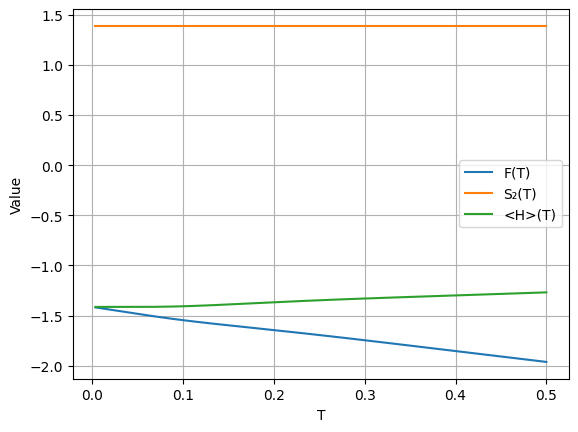

In [5]:
Ts = np.linspace(0.001, 0.5, 200)

F_vals  = [free_energy(-0.5, -1, T) for T in Ts]
S2_vals = [renyi2_entropy(-0.5, -1, T) for T in Ts]
H_vals  = [internal_energy(-0.5, -1, T) for T in Ts]

plt.plot(Ts, F_vals, label="F(T)")
plt.plot(Ts, S2_vals, label="S₂(T)")
plt.plot(Ts, H_vals, label="<H>(T)")

plt.xlabel("T")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from scipy.optimize import minimize
kB = 1.380649e-23  # Boltzmann constant


# ---------------------------
# Hamiltoniano
# ---------------------------
def H_system(g, v):
    return np.array([
        [v, g, g, 0],
        [g, -v, 0, g],
        [g, 0, -v, g],
        [0, g, g, v]
    ], dtype=float)

def H_total(g, v):
    return np.kron(H_system(g, v), np.eye(4))


# ---------------------------
# Parámetros de la densidad rho = A A^\dagger / Tr
# A es matriz compleja NxN con parámetros libres
# ---------------------------
def unpack_A(params, dim):
    """Convierte un vector real a una matriz compleja A de dimension dim x dim."""
    n = dim * dim
    real = params[:n]
    imag = params[n:]
    return (real + 1j * imag).reshape(dim, dim)

def make_rho(A):
    """Construye rho = A A† / Tr(AA†) (estado físico por construcción)."""
    M = A @ A.conj().T
    return M / np.trace(M)


# ---------------------------
# Entropía de Renyi-2
# ---------------------------
def S2_entropy(rho):
    purity = np.real(np.trace(rho @ rho))
    return -np.log(purity)


# ---------------------------
# Funcional F₂ = <H> - kB * T * S₂
# ---------------------------
def F2_functional(params, H, T):
    dim = H.shape[0]
    A = unpack_A(params, dim)
    rho = make_rho(A)
    E = np.real(np.trace(rho @ H))
    S2 = S2_entropy(rho)
    return E - kB * T * S2


# ---------------------------
# Minimización
# ---------------------------
def minimize_F2(g, v, T):
    H = H_total(g, v)
    dim = H.shape[0]

    # número de parámetros reales (A complejo dimxdim)
    nparams = 2 * dim * dim

    # condición inicial: A = identidad
    x0 = np.zeros(nparams)
    x0[:dim*dim] = 1.0  # parte real = matriz identidad

    res = minimize(F2_functional, x0, args=(H, T), method="BFGS")

    A_opt = unpack_A(res.x, dim)
    rho_opt = make_rho(A_opt)

    return rho_opt, res.fun


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.optimize import minimize

# Hamiltoniano para 2 espines del sistema
def H_system(g, v):
    return np.array([
        [v, g, g, 0],
        [g, -v, 0, g],
        [g, 0, -v, g],
        [0, g, g, v]
    ], dtype=complex)

# Matriz identidad para las ancillas
I2 = np.eye(4, dtype=complex)

# Hamiltoniano total para 4 espines: H_sistema ⊗ I_ancillas
def H_total(g, v):
    return np.kron(H_system(g, v), I2)

# Estado fundamental
def ground_state(H):
    eigenvalues, eigenvectors = eigh(H)
    return eigenvectors[:, 0]

# Matriz densidad total |psi><psi|
def rho_total(psi):
    return np.outer(psi, np.conj(psi))

# Matriz densidad reducida del sistema
def rho_system(psi):
    rho_t = rho_total(psi)
    
    # Reorganizar: sistema (2,2) ⊗ ancillas (2,2)
    rho_reshaped = rho_t.reshape(2, 2, 2, 2, 2, 2, 2, 2)
    
    # Trazar sobre ancillas (índices 2,3,6,7)
    rho_reduced = np.tensordot(rho_reshaped, np.eye(2), axes=([2, 3, 6, 7], [0, 1, 0, 1]))
    
    return rho_reduced.reshape(4, 4)

# Entropía de Rényi de orden 2
def renyi_entropy2(rho):
    purity = np.trace(rho @ rho)
    return -np.log(np.real(purity))

# Función objetivo: <H> - T S₂
def objective_function(params, T):
    g, v = params
    H = H_total(g, v)
    psi_gs = ground_state(H)
    
    # Valor esperado de la energía
    energy_exp = np.real(psi_gs.conj().T @ H @ psi_gs)
    
    # Entropía de Rényi
    rho_sys = rho_system(psi_gs)
    S2 = renyi_entropy2(rho_sys)
    
    return energy_exp - T * S2

# Encontrar el ground state y minimizar F = <H> - T S₂
def find_optimal_parameters(T, g_guess=-0.5, v_guess=-1.0):
    """Encuentra los parámetros g, v que minimizan F = <H> - T S₂"""
    initial_guess = [g_guess, v_guess]
    
    # Minimizar la función objetivo
    result = minimize(objective_function, initial_guess, args=(T,),
                     bounds=[(-2, 2), (-2, 2)], method='L-BFGS-B')
    
    return result.x, result.fun

# Análisis para diferentes temperaturas
T_values = np.linspace(0.01, 2.0, 50)
optimal_g = []
optimal_v = []
min_F_values = []
S2_values = []
energy_values = []

for T in T_values:
    (g_opt, v_opt), F_min = find_optimal_parameters(T)
    
    # Calcular propiedades en el óptimo
    H_opt = H_total(g_opt, v_opt)
    psi_opt = ground_state(H_opt)
    energy_exp = np.real(psi_opt.conj().T @ H_opt @ psi_opt)
    rho_sys = rho_system(psi_opt)
    S2 = renyi_entropy2(rho_sys)
    
    optimal_g.append(g_opt)
    optimal_v.append(v_opt)
    min_F_values.append(F_min)
    S2_values.append(S2)
    energy_values.append(energy_exp)

# Gráficos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Parámetros óptimos
ax1.plot(T_values, optimal_g, 'b-', label='g óptimo', linewidth=2)
ax1.plot(T_values, optimal_v, 'r-', label='v óptimo', linewidth=2)
ax1.set_xlabel('T')
ax1.set_ylabel('Parámetro')
ax1.set_title('Parámetros óptimos vs Temperatura')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Energía libre mínima
ax2.plot(T_values, min_F_values, 'g-', linewidth=2)
ax2.set_xlabel('T')
ax2.set_ylabel('F mínima')
ax2.set_title('Energía Libre Mínima F = <H> - T S₂')
ax2.grid(True, alpha=0.3)

# Entropía de Rényi
ax3.plot(T_values, S2_values, 'purple', linewidth=2)
ax3.set_xlabel('T')
ax3.set_ylabel('S₂')
ax3.set_title('Entropía de Rényi de orden 2')
ax3.grid(True, alpha=0.3)

# Energía esperada
ax4.plot(T_values, energy_values, 'orange', linewidth=2)
ax4.set_xlabel('T')
ax4.set_ylabel('<H>')
ax4.set_title('Energía Esperada')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar algunos valores
print("Resultados para diferentes temperaturas:")
for i in range(0, len(T_values), 10):
    T = T_values[i]
    print(f"T = {T:.2f}: g = {optimal_g[i]:.3f}, v = {optimal_v[i]:.3f}, "
          f"F = {min_F_values[i]:.3f}, S₂ = {S2_values[i]:.3f}")

ValueError: axes don't match array